In [3]:
from pathlib import Path # dataset paths as a Path object

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns 

Matplotlib is building the font cache; this may take a moment.


## Continuous-field analysis - Issue #17

## Load the dataset

In [20]:
path = Path("../../data/allstate_claims_data.csv")
print(f"Loaded dataframe")

Loaded dataframe


In [21]:
df = pd.read_csv(path)
df.head()


,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


## Continuous field inventory

The analysis uses the 14 supplied continuous predictors, `cont1` through
`cont14`. This inventory remains fixed throughout the notebook.

In [26]:
CONTINUOUS_FIELDS = tuple(f"cont{i}" for i in range(1, 15)) # creates a tuple of continuous field names
TARGET = "loss"
EXPECTED_CONTINUOUS_COUNT = 14

missing_columns = [
    column
    for column in (*CONTINUOUS_FIELDS, TARGET) # appending TARGET to the tuple of continuous fields
    if column not in df.columns
]

if missing_columns:
    raise KeyError(f"Required columns are missing: {missing_columns}")

if len(CONTINUOUS_FIELDS) != EXPECTED_CONTINUOUS_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_CONTINUOUS_COUNT} continuous fields, "
        f"but found {len(CONTINUOUS_FIELDS)}."
    )

continuous_inventory = pd.DataFrame(
    {
        "field": CONTINUOUS_FIELDS,
        "dtype": [df[column].dtype for column in CONTINUOUS_FIELDS],
        "non_null_count": [
            df[column].notna().sum() for column in CONTINUOUS_FIELDS
        ],
        "missing_count": [
            df[column].isna().sum() for column in CONTINUOUS_FIELDS
        ],
    }
)

print(f"Confirmed {len(CONTINUOUS_FIELDS)} continuous predictors.")
continuous_inventory

Confirmed 14 continuous predictors.


,field,dtype,non_null_count,missing_count
0,cont1,float64,188318,0
1,cont2,float64,188318,0
2,cont3,float64,188318,0
3,cont4,float64,188318,0
4,cont5,float64,188318,0
5,cont6,float64,188318,0
6,cont7,float64,188318,0
7,cont8,float64,188318,0
8,cont9,float64,188318,0
9,cont10,float64,188318,0


## Distribution summary 

This table summarizes each continuous predictor's distribution, observed minimum and maximum, range width, missing-value count, and unique-value count. 

In [23]:
# Lets get all continuous fields and flip the rows and columns to get a better view of summary stats
continuous_summary = df.loc[:, CONTINUOUS_FIELDS].describe().T 

# get sum df of all missing values for each cont field
continuous_summary["missing_count"] = (
    df.loc[:, CONTINUOUS_FIELDS].isna().sum()
)

# get unique counts of each cont field
continuous_summary["unique_count"] = (
    df.loc[:, CONTINUOUS_FIELDS].nunique(dropna=True) # ignore missing values when counting unique values
)

# range shows us how tightly values are clustered around the mean
continuous_summary["range_width"] = (
    continuous_summary["max"] - continuous_summary["min"]
)

continuous_summary = continuous_summary.loc[
    list(CONTINUOUS_FIELDS), # convert tuple to list 
    # specify wanted fields for summary df
    [ 
        "count",
        "missing_count",
        "unique_count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "range_width",
    ],
]

continuous_summary

,count,missing_count,unique_count,mean,std,min,25%,50%,75%,max,range_width
cont1,188318.0,0,647,0.493861,0.187640,0.000016,0.346090,0.475784,0.623912,0.984975,0.984959
cont2,188318.0,0,33,0.507188,0.207202,0.001149,0.358319,0.555782,0.681761,0.862654,0.861505
cont3,188318.0,0,76,0.498918,0.202105,0.002634,0.336963,0.527991,0.634224,0.944251,0.941617
cont4,188318.0,0,112,0.491812,0.211292,0.176921,0.327354,0.452887,0.652072,0.954297,0.777376
cont5,188318.0,0,141,0.487428,0.209027,0.281143,0.281143,0.422268,0.643315,0.983674,0.702531
cont6,188318.0,0,2573,0.490945,0.205273,0.012683,0.336105,0.440945,0.655021,0.997162,0.984479
cont7,188318.0,0,5632,0.484970,0.178450,0.069503,0.350175,0.438285,0.591045,1.000000,0.930497
cont8,188318.0,0,201,0.486437,0.199370,0.236880,0.312800,0.441060,0.623580,0.980200,0.743320
cont9,188318.0,0,347,0.485506,0.181660,0.000080,0.358970,0.441450,0.566820,0.995400,0.995320
cont10,188318.0,0,174,0.498066,0.185877,0.000000,0.364580,0.461190,0.614590,0.994980,0.994980


## Continuous-field distributions

Each continuous predictor is shown with a histogram and kernel density
estimate, followed by a boxplot. The histogram shows the distribution's shape,
while the boxplot highlights its median, spread, and potential outliers.

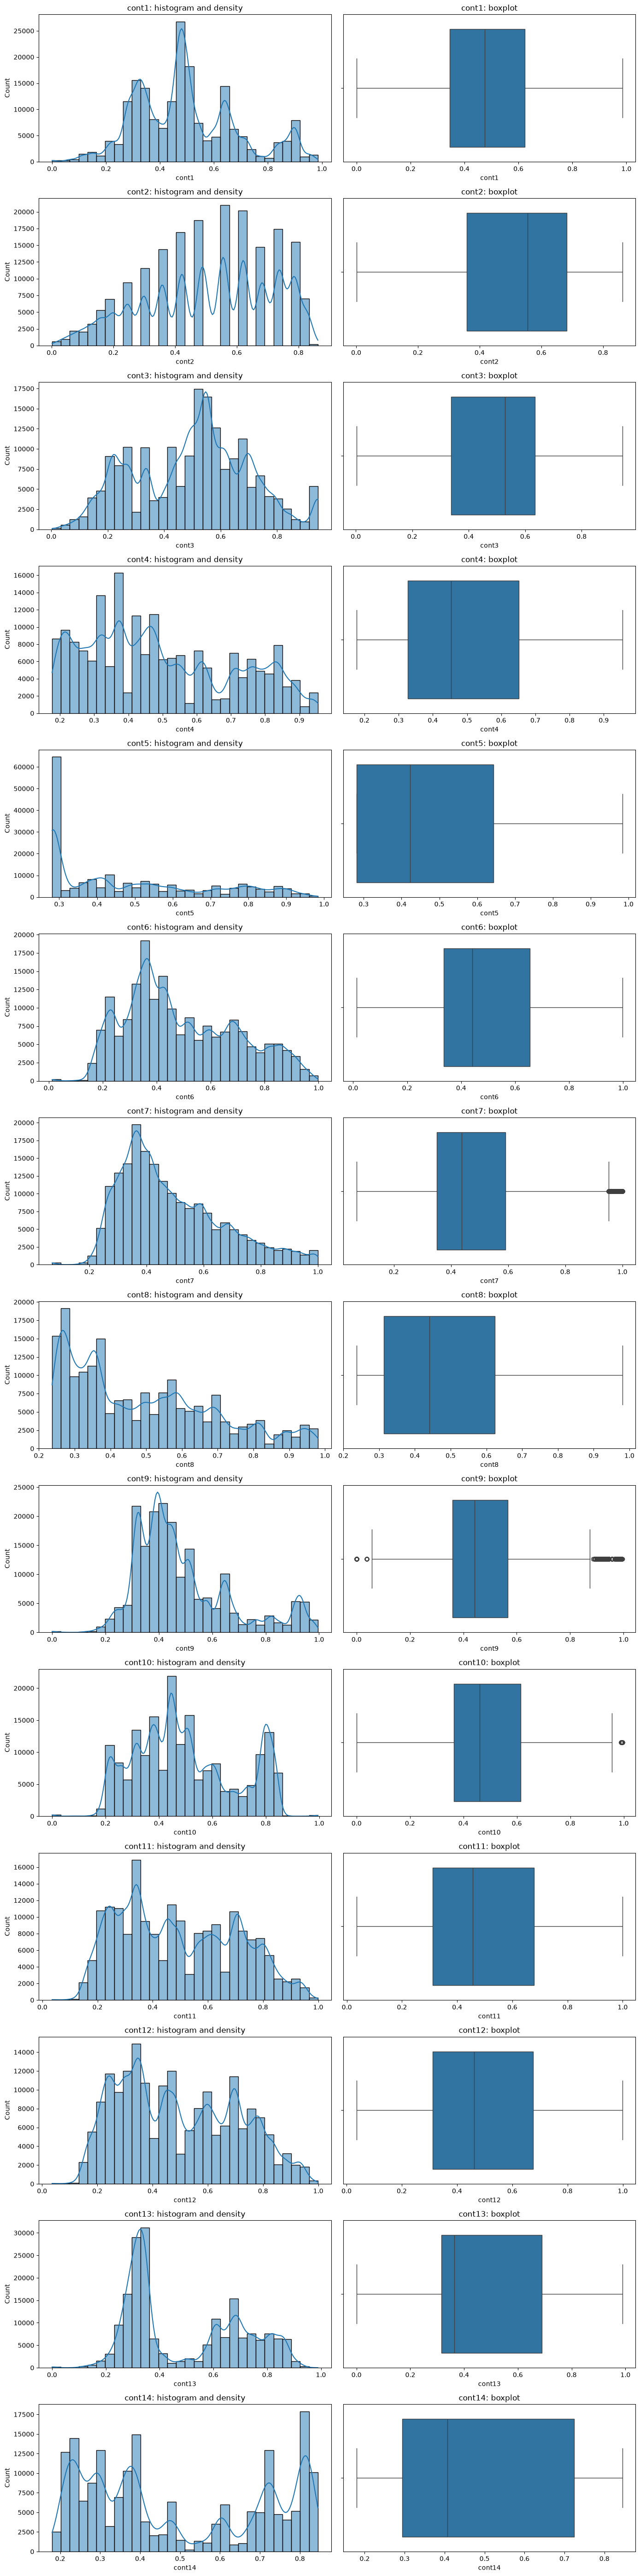

In [24]:
# create subplots for each cont field, creates rows and each row contains 2 columns, one for histogram and one for boxplot
fig, axes = plt.subplots(
    nrows=len(CONTINUOUS_FIELDS),
    ncols=2,
    figsize=(14, 4 * len(CONTINUOUS_FIELDS)),
)

for row, field in enumerate(CONTINUOUS_FIELDS):
    sns.histplot(
        data=df,
        x=field,
        bins=30,
        kde=True,
        ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"{field}: histogram and density")
    axes[row, 0].set_ylabel("Count")

    sns.boxplot(
        data=df,
        x=field,
        ax=axes[row, 1],
    )
    axes[row, 1].set_title(f"{field}: boxplot")

plt.tight_layout()
plt.show()

## Marginal target correlations

Pearson and Spearman correlations are calculated against raw `loss` and
`log1p(loss)`. These coefficients describe marginal associations between one
predictor and the target; they are not feature-importance scores.


In [36]:
# Spearman correlation is a non-parametric measure of rank correlation (statistical dependence between the rankings of two variables). It assesses how well the relationship between two variables can be described using a monotonic function. The Spearman correlation coefficient is denoted by the symbol ρ (rho) or rs.

# Pearson correlation measures the linear relationship between two continuous variables. It assumes that the data is normally distributed and that the relationship between the variables is linear. The Pearson correlation coefficient is denoted by the symbol r.

if (df[TARGET] < 0).any():
    raise ValueError("log1p(loss) requires all loss values to be non-negative.")

# obtains the log1p of the target variable to reduce skewness and handle zero values
loss_log1p = np.log1p(df[TARGET])

correlation_rows = []

for field in CONTINUOUS_FIELDS:
    correlation_rows.append(
        {
            "field": field,
            "pearson_loss": df[field].corr(
                df[TARGET],
                method="pearson",
            ),
            "spearman_loss": df[field].corr(
                df[TARGET],
                method="spearman",
            ),
            "pearson_log1p_loss": df[field].corr(
                loss_log1p,
                method="pearson",
            ),
            "spearman_log1p_loss": df[field].corr(
                loss_log1p,
                method="spearman",
            ),
        }
    )

target_correlations = (
    pd.DataFrame(correlation_rows)
    .set_index("field")
)

target_correlations.style.format("{:.4f}").background_gradient(
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

target_correlations

,pearson_loss,spearman_loss,pearson_log1p_loss,spearman_log1p_loss
field,,,,
cont1,-0.010237,-0.017641,-0.007335,-0.017641
cont2,0.141528,0.080066,0.104666,0.080066
cont3,0.111053,0.068353,0.081548,0.068353
cont4,-0.035831,-0.027878,-0.027523,-0.027878
cont5,-0.011355,-0.015114,-0.014958,-0.015114
cont6,0.040967,0.019697,0.031517,0.019697
cont7,0.119799,0.054928,0.085095,0.054928
cont8,0.030508,0.027495,0.032042,0.027495
cont9,0.014456,0.004401,0.017417,0.004401


## Quantile-bin continuous predictors

Each continuous field is divided into a requested default of 10 quantile bins.
If repeated values produce duplicate bin boundaries, those boundaries are
dropped and the actual number of bins is recorded.

In [37]:
# Quantile bins are used to divide continuous variables into discrete intervals based on their distribution. This technique is particularly useful for handling skewed data, as it ensures that each bin contains approximately the same number of observations. By using quantile bins, we can transform continuous variables into categorical ones, which can be beneficial for certain machine learning algorithms that perform better with categorical inputs. Additionally, quantile binning can help in identifying patterns and relationships between variables by simplifying the data structure.

DEFAULT_QUANTILE_BINS = 10

binned_fields = {}
bin_inventory_rows = []

for field in CONTINUOUS_FIELDS:
    valid_values = df[field].dropna()

    binned_values, bin_edges = pd.qcut(
        valid_values,
        q=DEFAULT_QUANTILE_BINS,
        duplicates="drop",
        retbins=True,
    )

    binned_field = pd.Series(
        pd.NA,
        index=df.index,
        dtype=binned_values.dtype,
        name=f"{field}_bin",
    )

    # valid_values.index gives us the original indices of the non-missing values in the DataFrame. By using this index, we can assign the binned values back to their corresponding positions in the binned_field Series, while keeping the missing values as pd.NA.
    binned_field.loc[valid_values.index] = binned_values

    actual_bin_count = len(bin_edges) - 1

    binned_fields[field] = binned_field
    bin_inventory_rows.append(
        {
            "field": field,
            "requested_bin_count": DEFAULT_QUANTILE_BINS,
            "actual_bin_count": actual_bin_count,
            "missing_value_count": df[field].isna().sum(),
        }
    )

bin_inventory = (
    pd.DataFrame(bin_inventory_rows)
    .set_index("field")
)

bin_inventory

,requested_bin_count,actual_bin_count,missing_value_count
field,,,
cont1,10,10,0
cont2,10,9,0
cont3,10,10,0
cont4,10,10,0
cont5,10,8,0
cont6,10,10,0
cont7,10,10,0
cont8,10,10,0
cont9,10,10,0


## Target patterns across quantile bins

For each continuous-field bin, the table reports observation count (support),
mean loss, median loss, and the interquartile range of loss. The plots compare
bin support with the mean and median target patterns.


In [43]:
bin_summary_tables = {}

for field in CONTINUOUS_FIELDS:
    analysis_data = pd.DataFrame(
        {
            "bin": binned_fields[field],
            "loss": df[TARGET],
        }
    ).dropna(subset=["bin", "loss"])

    bin_summary = (
        analysis_data.groupby(
            "bin",
            observed=True,
            sort=False,
        )["loss"]
        .agg(
            support="size",
            mean_loss="mean",
            median_loss="median",
            loss_q1=lambda values: values.quantile(0.25),
            loss_q3=lambda values: values.quantile(0.75),
        )
        .reset_index()
    )

    bin_summary["loss_iqr"] = (
        bin_summary["loss_q3"] - bin_summary["loss_q1"]
    )
    bin_summary.insert(
        0,
        "field",
        field,
    )

    bin_summary_tables[field] = bin_summary

all_bin_summaries = pd.concat(
    bin_summary_tables.values(),
    ignore_index=True,
)

all_bin_summaries.head(10)


,field,bin,support,mean_loss,median_loss,loss_q1,loss_q3,loss_iqr
0,cont1,"(0.643, 0.773]",17941,2938.553535,2014.890,1184.6600,3648.2900,2463.6300
1,cont1,"(0.325, 0.373]",17328,3215.119048,2192.145,1208.5625,4175.8100,2967.2475
2,cont1,"(-0.000984, 0.283]",19251,3036.539403,2209.820,1228.3150,4013.9150,2785.6000
3,cont1,"(0.283, 0.325]",20166,3045.865114,2194.015,1214.1350,4019.0625,2804.9275
4,cont1,"(0.502, 0.555]",18512,3064.813792,2110.445,1175.8525,3924.5725,2748.7200
5,cont1,"(0.453, 0.476]",19216,3006.873916,2045.835,1147.8550,3802.7625,2654.9075
6,cont1,"(0.773, 0.985]",18525,3132.963475,2237.600,1352.8200,3799.6500,2446.8300
7,cont1,"(0.476, 0.502]",17969,3046.193525,2111.940,1200.0700,3926.4400,2726.3700
8,cont1,"(0.373, 0.453]",19430,3133.854527,2136.540,1216.3150,3943.3175,2727.0025
9,cont1,"(0.555, 0.643]",19980,2777.374131,1937.035,1133.5525,3410.5400,2276.9875


In [ ]:
# Lets inspect cont2's bin summary table 
bin_summary_tables["cont2"]

,field,bin,support,mean_loss,median_loss,loss_q1,loss_q3,loss_iqr
0,cont2,"(0.2, 0.299]",21001,2650.054737,2109.640,1218.3400,3543.2300,2324.8900
1,cont2,"(0.621, 0.737]",32172,3399.239682,2225.165,1232.6575,4342.0200,3109.3625
2,cont2,"(0.299, 0.358]",14370,2815.646257,2141.760,1221.4575,3769.4550,2547.9975
3,cont2,"(0.489, 0.556]",20975,3216.650567,2221.060,1242.2100,4234.7400,2992.5300
4,cont2,"(0.00014999999999999996, 0.2]",21257,2120.267592,1740.260,1078.0200,2753.3700,1675.3500
5,cont2,"(0.358, 0.489]",35670,3008.030695,2190.185,1224.8025,4003.9250,2779.1225
6,cont2,"(0.737, 0.786]",15475,3422.421956,2107.070,1180.4000,4188.8050,3008.4050
7,cont2,"(0.556, 0.621]",20190,3398.676783,2258.145,1258.0800,4392.2275,3134.1475
8,cont2,"(0.786, 0.863]",7208,3481.255580,2123.250,1158.5500,4238.9400,3080.3900


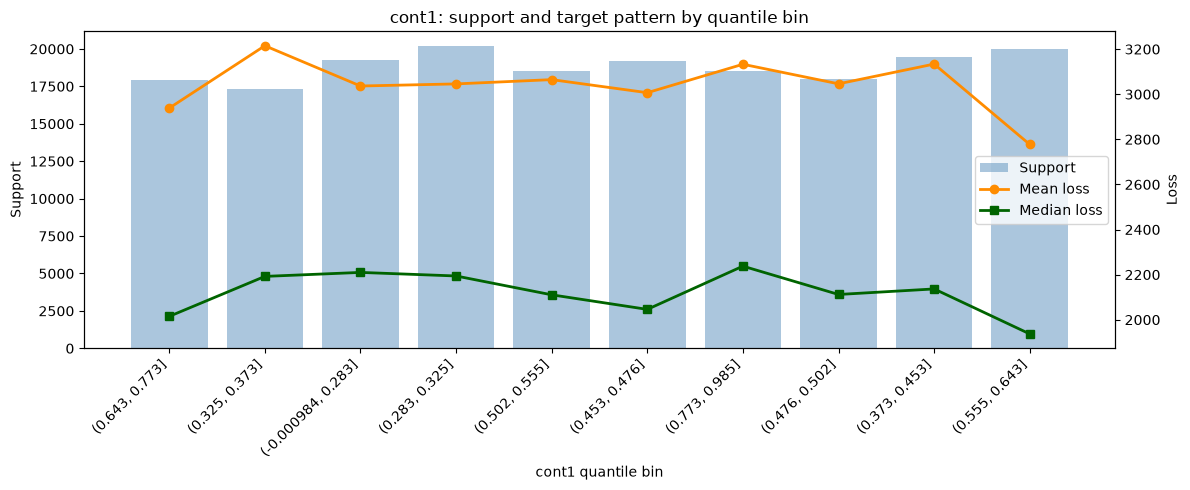

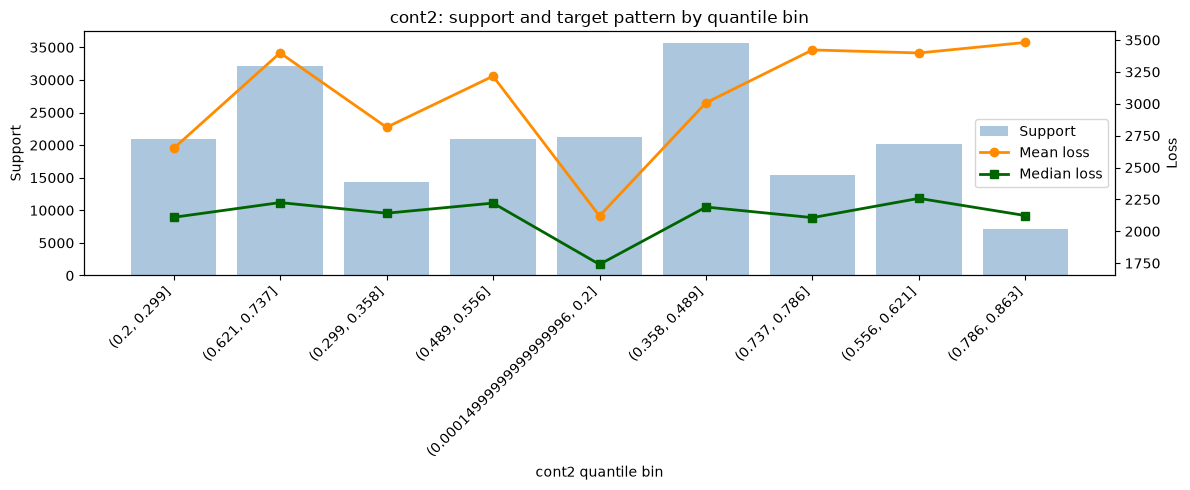

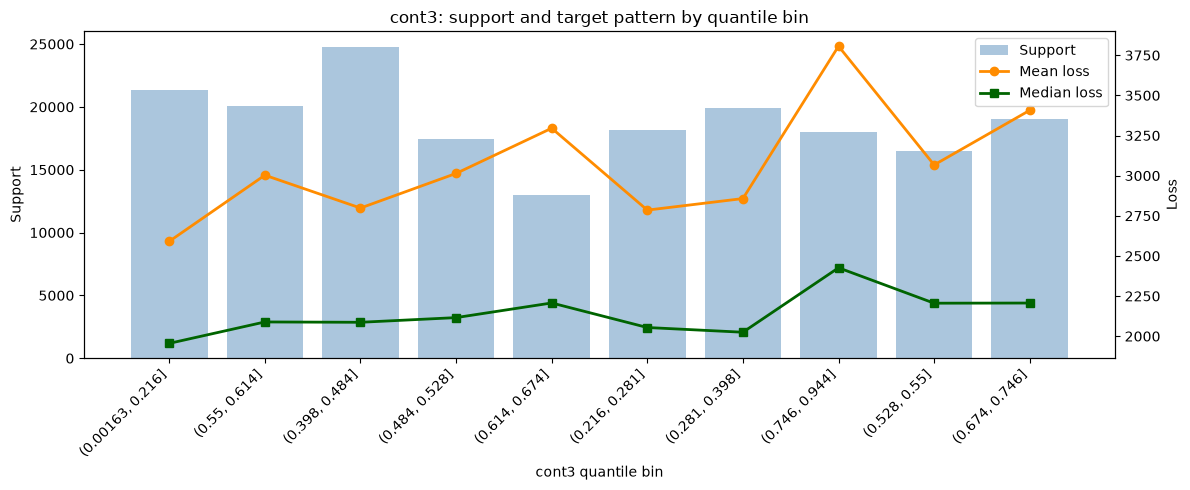

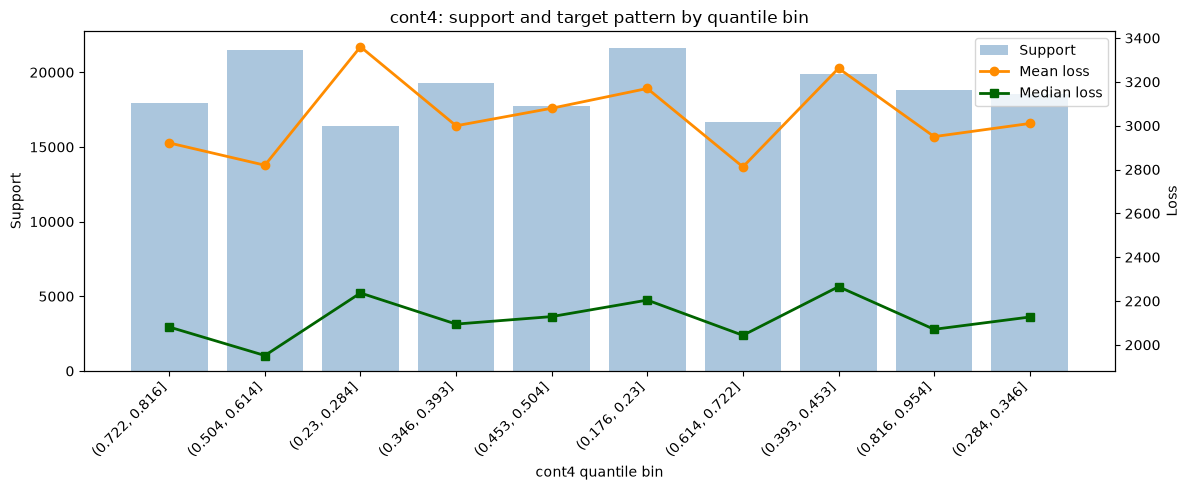

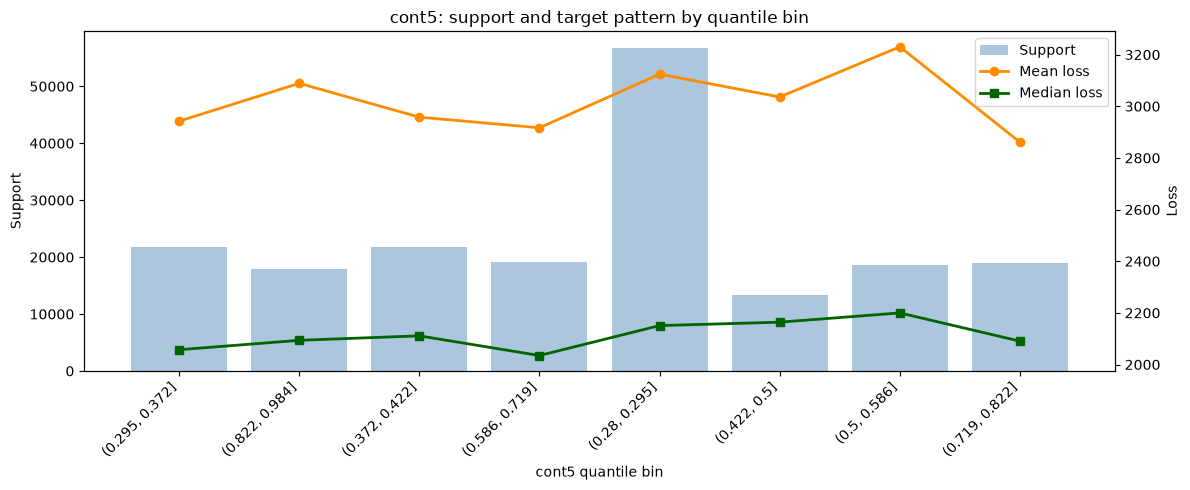

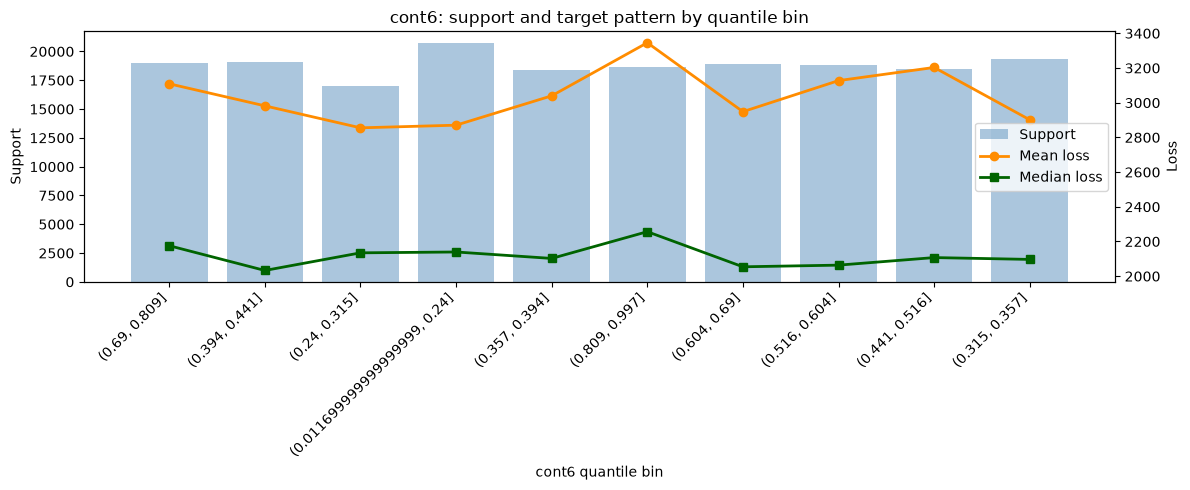

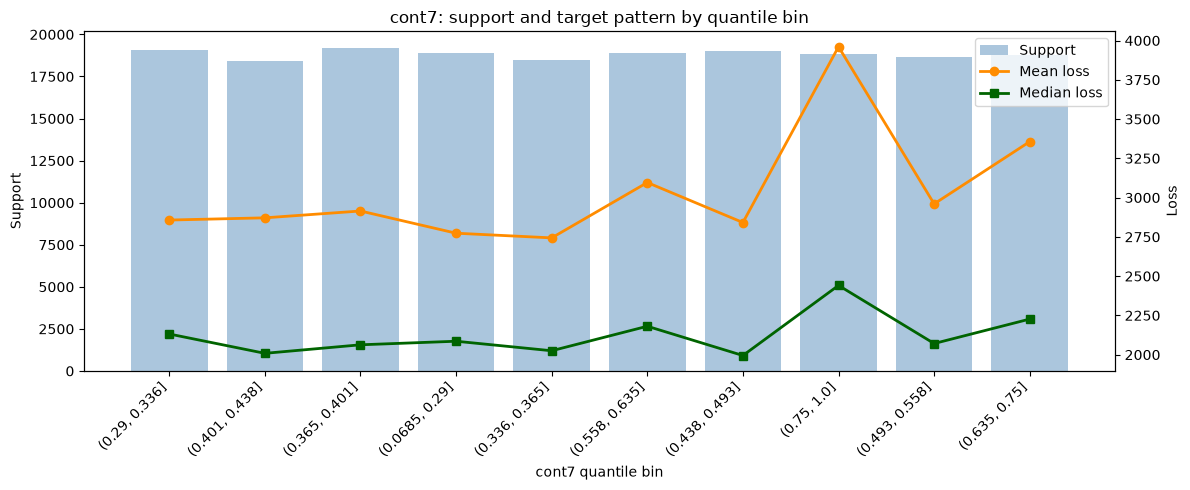

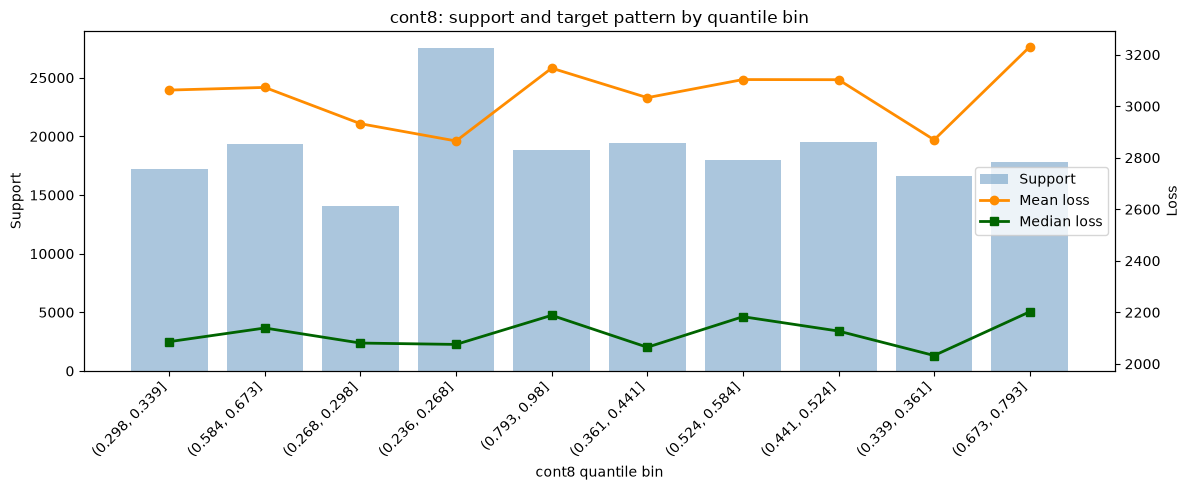

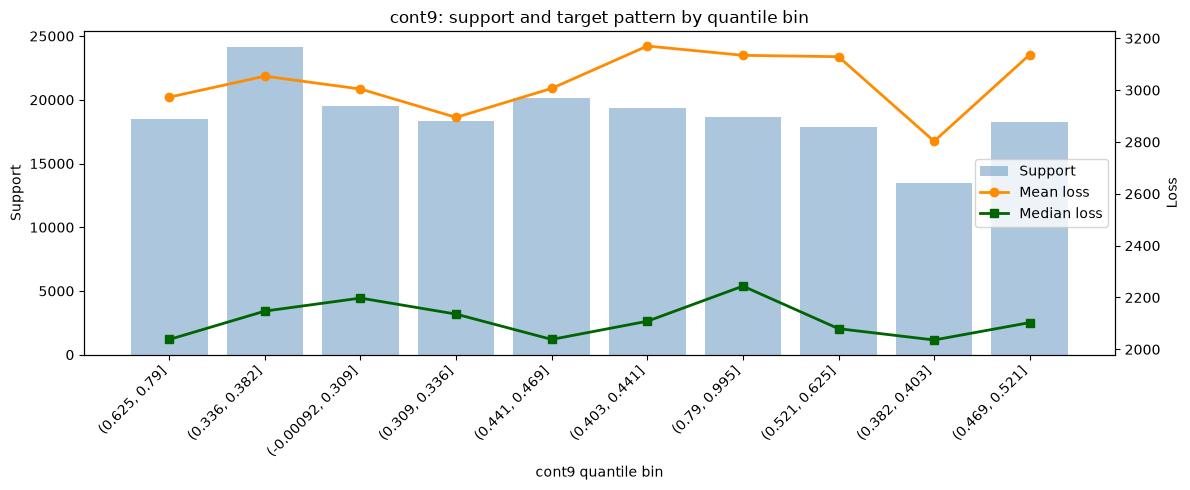

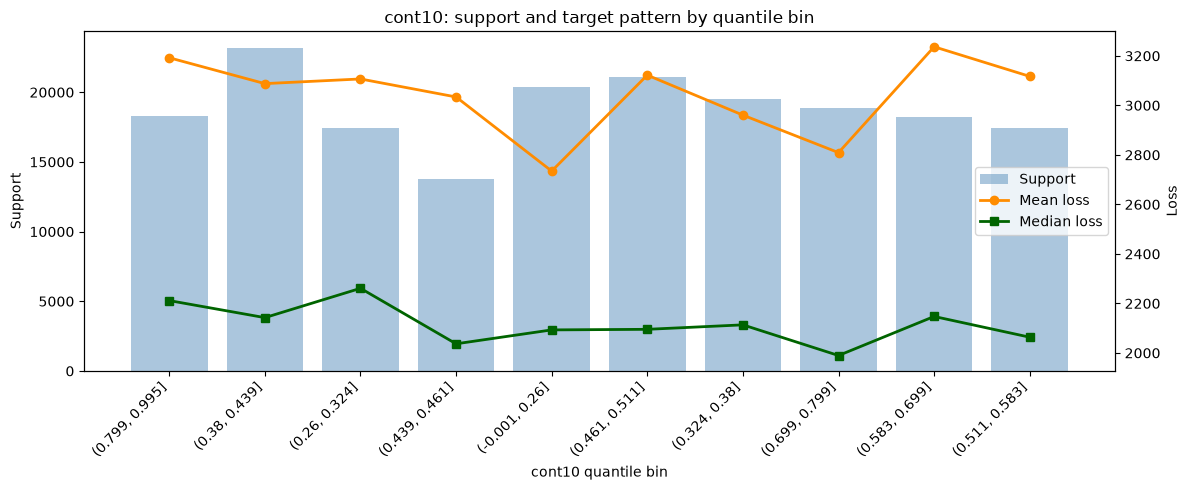

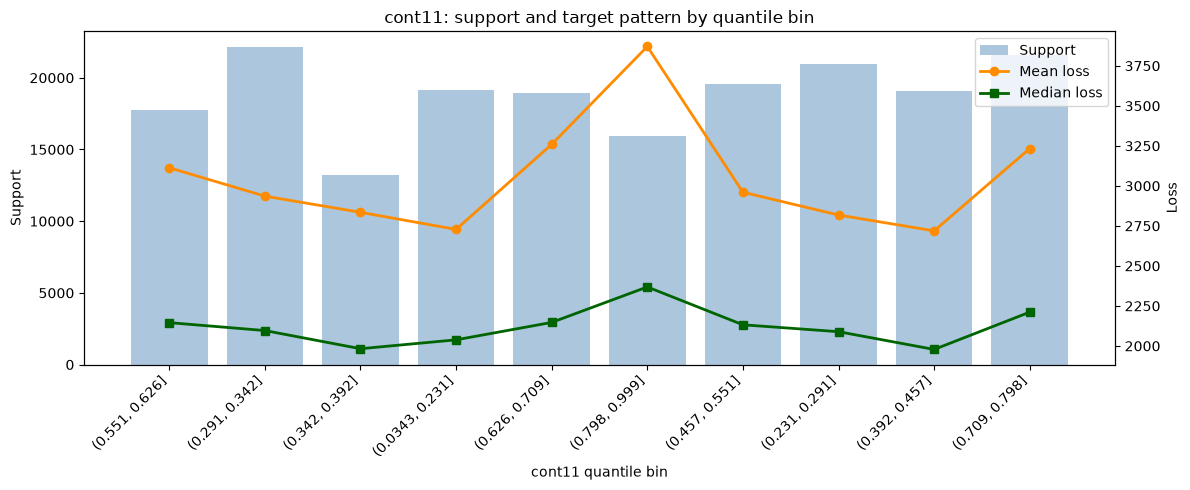

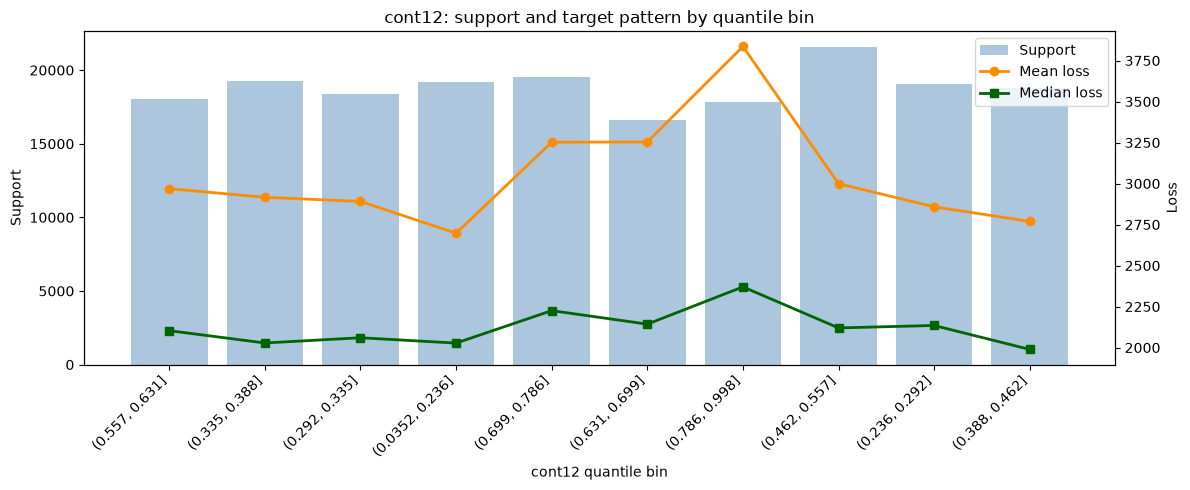

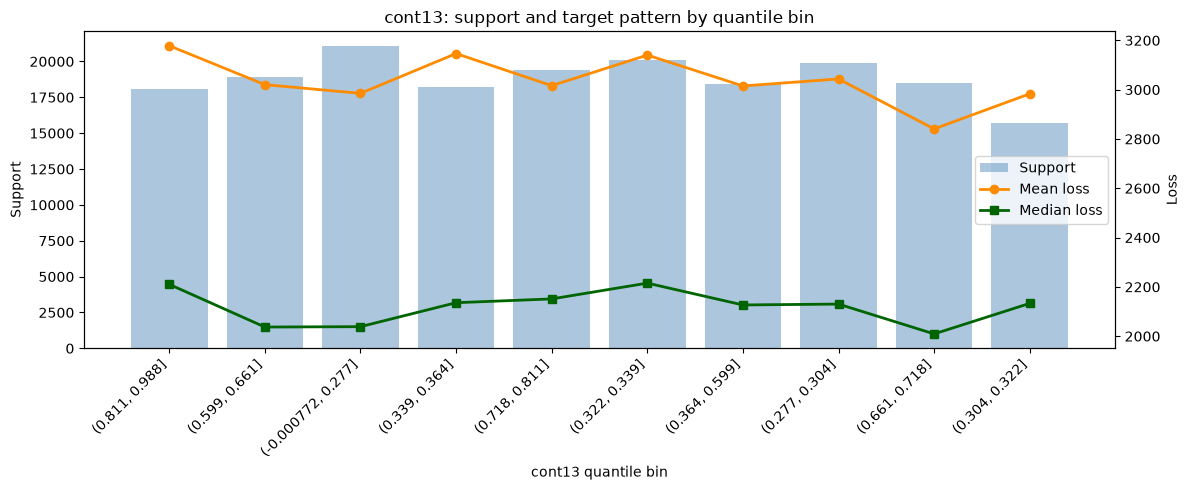

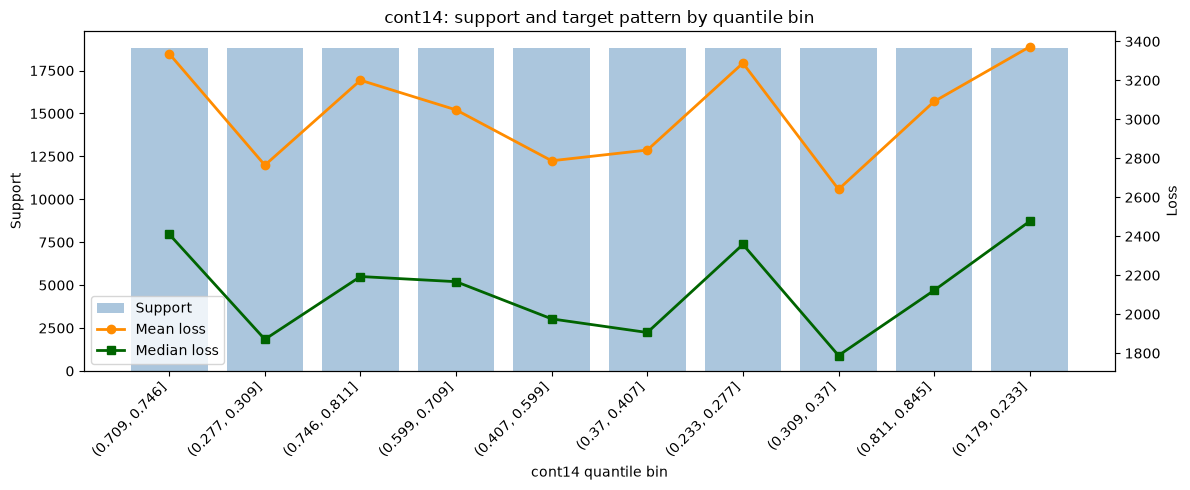

In [ ]:
for field in CONTINUOUS_FIELDS:
    plot_data = bin_summary_tables[field]
    x_positions = np.arange(len(plot_data))

    fig, support_axis = plt.subplots(figsize=(12, 5))
    loss_axis = support_axis.twinx()

    # support refers to the number of observations (individual rows) in each quantile bin 
    support_axis.bar(
        x_positions,
        plot_data["support"],
        color="steelblue",
        alpha=0.45,
        label="Support",
    )

    # mean_loss refers to the average loss value for each quantile bin
    loss_axis.plot(
        x_positions,
        plot_data["mean_loss"],
        color="darkorange",
        marker="o",
        linewidth=2,
        label="Mean loss",
    )

    # median_loss refers to the middle value of the loss distribution for each quantile bin
    loss_axis.plot(
        x_positions,
        plot_data["median_loss"],
        color="darkgreen",
        marker="s",
        linewidth=2,
        label="Median loss",
    )

    support_axis.set_xticks(x_positions)
    support_axis.set_xticklabels(
        plot_data["bin"].astype(str),
        rotation=45,
        ha="right",
    )

    support_axis.set_xlabel(f"{field} quantile bin")
    support_axis.set_ylabel("Support")
    loss_axis.set_ylabel("Loss")
    support_axis.set_title(
        f"{field}: support and target pattern by quantile bin"
    )

    support_handles, support_labels = (
        support_axis.get_legend_handles_labels()
    )
    loss_handles, loss_labels = loss_axis.get_legend_handles_labels()

    loss_axis.legend(
        support_handles + loss_handles,
        support_labels + loss_labels,
        loc="best",
    )

    plt.tight_layout()
    plt.show()

## Continuous-predictor correlation heatmap

This heatmap displays pairwise Pearson correlations among the 14 continuous
predictors. These are associations between predictors and are not measures of
feature importance.

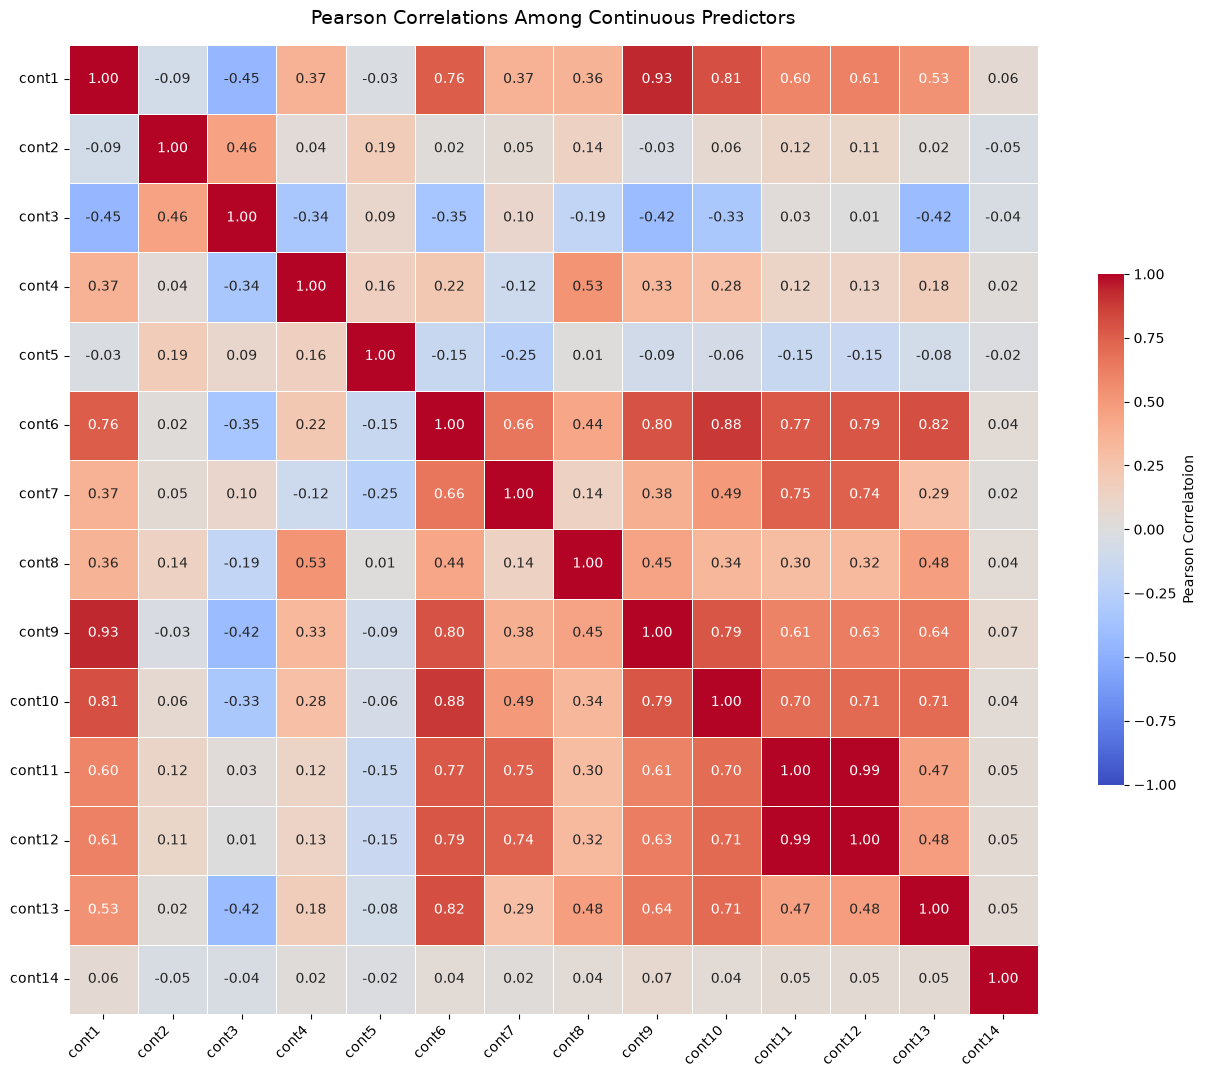

In [ ]:
predictor_correlations = df.loc[:, CONTINUOUS_FIELDS].corr(method="pearson")

# Heatmap visualization of the Pearson correlations among continuous predictors, showing the strenght and direction of the linear relationships among them. Red indicates a strong positive correlation, blue indicates a strong negative correlation, and white indicates no correlation. The diagonal elements are always 1, as each variable is perfectly correlated with itself.

plt.figure(figsize=(13, 11))

# Create a heatmap to visualize the Pearson correlations among continuous predictors
sns.heatmap(
  predictor_correlations,
  annot=True, 
  fmt=".2f",
  cmap="coolwarm", 
  vmin=-1,
  vmax=1, 
  square=True, 
  linewidths=0.5,
  center=0, 
  cbar_kws={
    "label": "Pearson Correlatoion",
    "shrink": 0.5},
)

plt.title(
    "Pearson Correlations Among Continuous Predictors",
    fontsize=14,
    pad=15,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## September feature-retention decision

All 14 continuous predictors are retained for the September analysis.

Weak Pearson or Spearman correlation with `loss` or `log1p(loss)` is not, by
itself, evidence that a predictor is unhelpful. These coefficients measure only
marginal linear or monotonic associations and may not capture nonlinear
relationships or interactions with other predictors.

Likewise, strong predictor–predictor correlation is not, by itself, a reason to
remove a feature. Correlated predictors will be investigated during later
modeling and validation, where their effect can be evaluated in the context of
the selected model.

Therefore, no continuous feature will be removed during September solely
because it has weak target correlation or strong correlation with another
predictor.

In [53]:
feature_decisions = pd.DataFrame(
    {
        "field": CONTINUOUS_FIELDS,
        "september_status": "Retained",
        "removal_based_on_target_correlation": False,
        "removal_based_on_predictor_correlation": False,
    }
)

assert len(feature_decisions) == 14
assert feature_decisions["september_status"].eq("Retained").all()

feature_decisions

,field,september_status,removal_based_on_target_correlation,removal_based_on_predictor_correlation
0,cont1,Retained,False,False
1,cont2,Retained,False,False
2,cont3,Retained,False,False
3,cont4,Retained,False,False
4,cont5,Retained,False,False
5,cont6,Retained,False,False
6,cont7,Retained,False,False
7,cont8,Retained,False,False
8,cont9,Retained,False,False
9,cont10,Retained,False,False


### Validation cell confirming all required fields are covered

In [54]:
assert len(CONTINUOUS_FIELDS) == 14
assert set(continuous_summary.index) == set(CONTINUOUS_FIELDS)
assert set(target_correlations.index) == set(CONTINUOUS_FIELDS)
assert set(bin_inventory.index) == set(CONTINUOUS_FIELDS)
assert set(bin_summary_tables) == set(CONTINUOUS_FIELDS)
assert predictor_correlations.shape == (14, 14)

print("Task 7 validation complete: all 14 continuous fields are covered.")

Task 7 validation complete: all 14 continuous fields are covered.
